In [2]:
%load_ext autoreload
%autoreload 2

import queries

query = queries.queries()
query.load_data()

Loaded dataframes/players.csv into table players
Loaded dataframes/matches.csv into table matches
Loaded dataframes/events.csv into table events
Loaded dataframes/teams.csv into table teams
Loaded dataframes/positions.csv into table positions
Loaded dataframes/event_tags.csv into table event_tags
All files loaded into the database!


In [93]:
import pandas as pd
import numpy as np

# 1. Load your raw tables
events = query.query_this("SELECT events.*, positions.initialX, positions.initialY FROM events JOIN positions ON events.id = positions.id WHERE eventId = 10") # ID 10 is 'Shot'
tags = query.query_this("SELECT * FROM event_tags")
positions = query.query_this("SELECT * FROM positions")

# 2. Create the "Goal" flag
# We filter tags to find only the rows where tag == 101 (Goal)
goal_tags = tags[tags['tag'] == 101]

# 3. Create the 'is_goal' column
# We check if the event's ID exists in our list of 'goal_tags'
# np.where(condition, value_if_true, value_if_false)
events['is_goal'] = np.where(events['id'].isin(goal_tags['event_id']), 1, 0)

# 4. Add positions 


# NOW you have a clean table with 1 row per shot, and a target column
print(events[['id', 'playerId', 'is_goal']].head())

          id  playerId  is_goal
0  177959212     25413        1
1  177959247     26150        0
2  177959280     14763        1
3  177959289      7868        0
4  177959429      7868        0


In [94]:
events

,eventId,subEventName,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,initialX,initialY,is_goal
0,10,Shot,25413,2499719,Shot,1609,1H,94.595788,100.0,177959212,88,41,1
1,10,Shot,26150,2499719,Shot,1631,1H,179.854785,100.0,177959247,85,52,0
2,10,Shot,14763,2499719,Shot,1631,1H,254.745027,100.0,177959280,96,52,1
3,10,Shot,7868,2499719,Shot,1609,1H,425.824035,100.0,177959289,81,33,0
4,10,Shot,7868,2499719,Shot,1609,1H,815.462015,100.0,177959429,75,30,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8446,10,Shot,8561,2500098,Shot,1633,2H,1972.969422,100.0,251596053,72,45,0
8447,10,Shot,41174,2500098,Shot,1633,2H,2193.887080,100.0,251596096,86,33,1
8448,10,Shot,7879,2500098,Shot,1623,2H,2377.197700,100.0,251596357,88,62,0
8449,10,Shot,145692,2500098,Shot,1623,2H,2381.481625,100.0,251596359,92,38,0


In [4]:
len(events[events["is_goal"] == 1])

914

In [5]:
len(events["playerId"].unique())

426

In [32]:
players_id = events["playerId"].unique()
players_id

array([ 25413,  26150,  14763,   7868,   7945,  49876,  14869, 120339,
        12829,   3319, 167145,   7870,  26010, 340386,  70083, 105339,
         9097,  70086,   8325,    466,   8242,  38021,   8944,  14748,
         9127,   8032,   8433,   7892,  31528,   9623,  38093,   3324,
         9419, 279709, 303357, 214654, 235555,  55979,   8422,  38031,
         8142,  14796,    454,   8186,   8554,   5911,  77548,  25706,
        15054,  20450,   7944,   9532, 293687,   7932,   8747,  15198,
        49872, 105338,     38, 397178,  70122,   7905,   8561,   7938,
       265318,  14703,   7936, 134513,   8582,   7941,  12536,  11152,
           54,   8717,  13484, 136441, 210044,  70215,   8004,  20857,
          383,   7885, 343951,   8144,   8116,  70389,  61988,    703,
          262,   8192, 215983,   8953,  20593,  20505,  25747,  28292,
         7888, 120353,   4908,  14870,  25393,  92899,    116,  21160,
       377071,   8958,   9414,   8530, 119951,  86308,   8351,   9283,
      

In [42]:
class Player:

    def __init__(self, playerId, query):
        self.playerId = playerId
        self.query = query
        self.goals_by_player = events[(events["is_goal"] == 1) & (events["playerId"] == playerId)]
        self.shots_by_player = events[events["playerId"] == playerId]
        
    def get_details(self):
        return self.query.get_player_by_id(self.playerId)

    def get_shot_count(self):
        return len(self.shots_by_player)

    def get_goal_count(self):
        return len(self.goals_by_player)
        
    def get_conversion_rate(self):
        conversion_rate = len(self.goals_by_player)/len(self.shots_by_player)
        return conversion_rate

In [48]:
myPlayer = Player(3319, query)

In [50]:
a = myPlayer.get_details()
a

,weight,firstName,middleName,lastName,currentTeamId,birthDate,height,wyId,foot,shortName,currentNationalTeamId
0,76,Mesut,None,\u00d6zil,1609.0,1988-10-15,180,3319,left,M. \u00d6zil,3148.0


In [74]:
player_conversion_df = pd.DataFrame(columns=['playerId', 'name', 'shots', 'goals', 'conversionRate'])


for player_id in players_id:
    myPlayer = Player(player_id, query)
    player_details = myPlayer.get_details()
    player_shots = myPlayer.get_shot_count()
    player_goals = myPlayer.get_goal_count()
    player_conversion = myPlayer.get_conversion_rate()

    new_row_df = pd.DataFrame({'playerId': player_id,
                               'name': player_details["firstName"] + " " + player_details["lastName"],
                               'shots': player_shots,
                               'goals': player_goals,
                               'conversionRate': player_conversion, 
                                })
    player_conversion_df = pd.concat([player_conversion_df, new_row_df], ignore_index=True)

    
#player_conversion_rate = sorted(player_conversion_rate.items(), key=lambda x: x[1], reverse=True)
player_conversion_df.sort_values("goals", ascending=False).head(15)

/var/folders/br/lnqxbh590w5f7n1cs9zmlw000000gn/T/ipykernel_74555/586431890.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  player_conversion_df = pd.concat([player_conversion_df, new_row_df], ignore_index=True)


,playerId,name,shots,goals,conversionRate
97,120353,Mohamed Salah Ghaly,136,31,0.227941
73,8717,Harry Kane,162,27,0.166667
18,8325,Sergio Leonel Ag\u00fcero del Castillo,86,17,0.197674
158,11066,Raheem Shaquille Sterling,79,17,0.215190
61,7905,Romelu Lukaku Menama,76,16,0.210526
8,12829,Jamie Vardy,60,15,0.250000
149,15808,Roberto Firmino Barbosa de Oliveira,79,14,0.177215
13,340386,Gabriel Fernando de Jesus,53,13,0.245283
0,25413,Alexandre Lacazette,63,12,0.190476
208,14911,Heung-Min Son,70,12,0.171429


In [75]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Shots vs Converstion Rate')

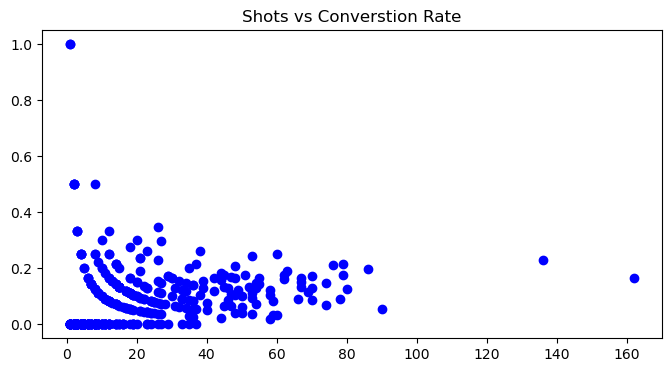

In [76]:
plt.figure(figsize=(8, 4)) # Optional: set figure size
plt.scatter(player_conversion_df["shots"], player_conversion_df["conversionRate"], color='blue') # Pl
plt.title('Shots vs Converstion Rate') # Add title

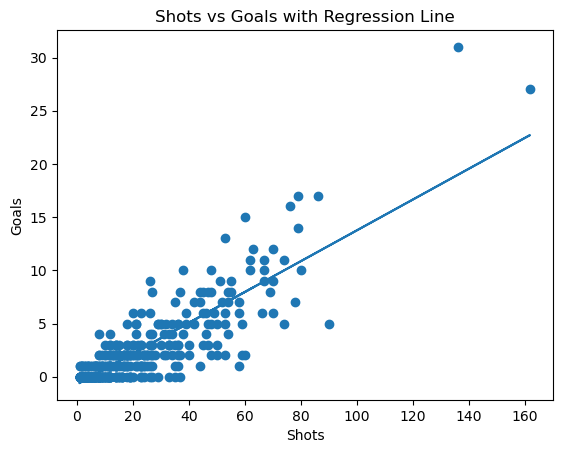

In [81]:
from sklearn.linear_model import LinearRegression

x = player_conversion_df["shots"].values.reshape(-1, 1)
y = player_conversion_df["goals"].values

model = LinearRegression()
model.fit(x, y)

y_pred = model.predict(x)

plt.scatter(x, y)
plt.plot(x, y_pred)
plt.xlabel("Shots")
plt.ylabel("Goals")
plt.title("Shots vs Goals with Regression Line")
plt.show()


In [95]:
events

,eventId,subEventName,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,initialX,initialY,is_goal
0,10,Shot,25413,2499719,Shot,1609,1H,94.595788,100.0,177959212,88,41,1
1,10,Shot,26150,2499719,Shot,1631,1H,179.854785,100.0,177959247,85,52,0
2,10,Shot,14763,2499719,Shot,1631,1H,254.745027,100.0,177959280,96,52,1
3,10,Shot,7868,2499719,Shot,1609,1H,425.824035,100.0,177959289,81,33,0
4,10,Shot,7868,2499719,Shot,1609,1H,815.462015,100.0,177959429,75,30,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8446,10,Shot,8561,2500098,Shot,1633,2H,1972.969422,100.0,251596053,72,45,0
8447,10,Shot,41174,2500098,Shot,1633,2H,2193.887080,100.0,251596096,86,33,1
8448,10,Shot,7879,2500098,Shot,1623,2H,2377.197700,100.0,251596357,88,62,0
8449,10,Shot,145692,2500098,Shot,1623,2H,2381.481625,100.0,251596359,92,38,0


In [124]:
import math

def euclidean(shot_position):
    goal_position = (100, 50)
    return math.dist(shot_position, goal_position)



In [125]:
shot_positions = np.array(list(zip(events["initialX"], events["initialY"])))
shot_distance = np.array([euclidean(x) for x in shot_positions])
events["distance"] = shot_distance

In [126]:
events[events["is_goal"] == 1].sort_values("distance", ascending=False).head(15)

,eventId,subEventName,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,initialX,initialY,is_goal,distance
3056,10,Shot,7944,2499856,Shot,1623,2H,1254.782389,100.0,210484394,44,40,1,56.885851
6743,10,Shot,9739,2500019,Shot,1659,2H,1896.215943,100.0,234993548,73,19,1,41.109610
798,10,Shot,8717,2499752,Shot,1624,1H,1664.160104,100.0,185820216,79,85,1,40.816663
3777,10,Shot,25785,2499888,Shot,1624,1H,2373.032449,100.0,214471078,93,89,1,39.623226
2179,10,Shot,283142,2499814,Shot,1631,1H,1719.582174,100.0,201100966,85,14,1,39.000000
767,10,Shot,9206,2499751,Shot,1646,1H,170.935625,100.0,186144087,67,67,1,37.121422
6368,10,Shot,70122,2500001,Shot,1611,2H,2748.607624,100.0,232587707,67,67,1,37.121422
5084,10,Shot,120353,2499943,Shot,1612,2H,1323.837327,100.0,220934410,67,34,1,36.674242
7743,10,Shot,38021,2500065,Shot,1625,2H,499.438484,100.0,245423267,72,73,1,36.235342
7656,10,Shot,7870,2500060,Shot,1609,2H,2177.835328,100.0,245379297,87,17,1,35.468296


In [130]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [147]:
# 1. Load Data
X = np.array(events[["initialX", "initialY"]])
y = np.array(events[["is_goal"]])

In [148]:
# 2. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [149]:
# 4. Initialize and Train Model
# random_state ensures reproducibility
model = LogisticRegression(class_weight='balanced', random_state=42) 
model.fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(class_weight='balanced', random_state=42)

In [150]:
# 5. Predict
y_pred = model.predict(X_test)

In [167]:
# Get probabilities for all test samples
goal_probs = model.predict_proba(X_test)

# View the first 5 results
print(goal_probs[:, 1])

[0.65324882 0.59008228 0.69864443 ... 0.69862654 0.74045821 0.16592161]


In [151]:
# 6. Evaluate
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.61

Confusion Matrix:
[[898 611]
 [ 46 136]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.60      0.73      1509
           1       0.18      0.75      0.29       182

    accuracy                           0.61      1691
   macro avg       0.57      0.67      0.51      1691
weighted avg       0.87      0.61      0.68      1691



## Calculate xGs for all the shots

In [171]:
xGs = model.predict_proba(X)[:, 1]

In [173]:
events["xGs"] = xGs

In [182]:
events[(events["is_goal"] == 1) & (events["teamId"] == 1625)].sort_values("xGs").head(15)

,eventId,subEventName,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,initialX,initialY,is_goal,distance,xGs
7743,10,Shot,38021,2500065,Shot,1625,2H,499.438484,100.0,245423267,72,73,1,36.235342,0.131296
2258,10,Shot,105339,2499818,Shot,1625,1H,879.706231,100.0,200655849,74,58,1,27.202941,0.152413
1756,10,Shot,105339,2499794,Shot,1625,2H,875.061613,100.0,196255567,74,67,1,31.064449,0.159051
2600,10,Shot,38021,2499834,Shot,1625,2H,192.228458,100.0,206732603,76,43,1,25.000000,0.176238
5938,10,Shot,8325,2499982,Shot,1625,2H,2679.581363,100.0,227275124,77,43,1,24.041631,0.195747
5712,10,Shot,70083,2499972,Shot,1625,1H,1277.543347,100.0,225711125,78,36,1,26.076810,0.210251
855,10,Shot,245364,2499754,Shot,1625,2H,2737.243355,100.0,185704462,77,60,1,25.079872,0.211199
1323,10,Shot,8464,2499774,Shot,1625,2H,2586.894650,100.0,190069355,82,33,1,24.758837,0.304826
7999,10,Shot,245364,2500078,Shot,1625,1H,724.868615,100.0,247535050,81,72,1,29.068884,0.324192
3094,10,Shot,11066,2499857,Shot,1625,2H,3002.901532,100.0,210514892,83,40,1,19.723083,0.341595


In [183]:
query.get_match_by_id(2500065)

,match_id,date,home_team,away_team,home_score,away_score,label,venue,gameweek,winner_team_id
0,2500065,2018-04-22 15:30:00,1625,10531,5,0,"Manchester City - Swansea City, 5 - 0",Etihad Stadium,35,1625


In [188]:
corr = events["initialY"].corr(events["xGs"])
print(corr)

0.09399504146535559


In [200]:
total_xgs_per_player = (
    events
    .groupby("playerId", as_index=False)["xGs"]
    .sum()
    .rename(columns={"xGs": "total_xGs"})
)
players = pd.merge(player_conversion_df, total_xgs_per_player, on="playerId")


In [202]:
players[players["shots"] > 10].sort_values("total_xGs", ascending=False).head(15)
players["unexpected_goals"] = np.arrayplayers["goal"] - players["total_xGs"]

KeyError: 'goal'